# Subspace synthesis on a Stiefel manifold

Most gate-synthesis problems do not actually care about the *whole* unitary. A
gate mediated by a bosonic mode only has to be right on the states where the
mode is in vacuum; a subspace encoding only has to be right on the code space.
Whatever the pulse does elsewhere is **redundancy**.

GEOPE can quotient that redundancy out instead of optimising over it, by
synthesising on a **Stiefel manifold**

$$\mathrm{St}_m(\mathbb C^N) = \{Q \in \mathbb C^{N\times m} : Q^\dagger Q = \mathbb 1_m\}
\;\cong\; \mathrm{SU}(N)/\mathrm{SU}(N-m),$$

whose points are orthonormal $m$-frames rather than full unitaries.

This notebook works the example from the paper: a **CZ gate on two spins,
mediated by a single bosonic mode**. The mode starts in vacuum, and where it
ends up is not part of the specification.

## 1. The problem

Two spins and one boson truncated at $d=2$ bosons, so the Fock space is
$\{|0\rangle, |1\rangle, |2\rangle\}$ and the full Hilbert space has
$N = 4(d+1) = 12$ dimensions. We score only the $m = 4$ spin states with the
boson in vacuum.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from geope import Geope, History, Parameters, Stiefel
from geope.utils import (
    construct_full_spin_boson_basis,
    construct_restricted_spin_boson_basis,
)

TRUNC = 2                    # maximum boson number
FOCK = TRUNC + 1             # Fock-space dimension
N, M = 4 * FOCK, 4           # N = 12 ambient, m = 4 scored columns
print(f"ambient dimension N = {N}, frame size m = {M}")

ambient dimension N = 12, frame size m = 4


### The frame and the target

The basis is ordered `kron(spin_1, spin_2, boson)`, so the state
$|s\rangle \otimes |0\rangle$ is column `FOCK * s` of the identity. Those four
columns are the frame $E$ the pulse acts on, and the target is $E$ with the CZ
phases applied — i.e. $\pi(U_{\mathrm{CZ}} \otimes |0\rangle\langle 0| +
U_{\mathrm{arbitrary}})$, with the arbitrary block never written down.

In [2]:
E = np.zeros((N, M), dtype=complex)
for spin in range(M):
    E[FOCK * spin, spin] = 1.0

CZ = np.diag([1.0, 1.0, 1.0, -1.0]).astype(complex)
Q_target = E @ CZ

print("E^dag E = 1 :", np.allclose(np.conj(E).T @ E, np.eye(M)))
print("target shape:", Q_target.shape)

E^dag E = 1 : True
target shape: (12, 4)


### Controls

The spins couple to the mode through $\sigma^{x,y}_j \otimes \{q, p\}$ — a
Jaynes–Cummings-style interaction. The full spin-boson basis supplies the
algebra the projection is taken in.

In [3]:
algebra = construct_full_spin_boson_basis(2, 1, TRUNC)
controls = construct_restricted_spin_boson_basis(
    2, 1, {1: ["x", "y"], 2: ["x", "y"]}, TRUNC
)
print(f"algebra generators: {algebra.lie_algebra_dim}")
print(f"control generators: {controls.lie_algebra_dim}  {controls.labels}")

algebra generators: 45
control generators: 12  ['IXi', 'IXq', 'IXp', 'IYi', 'IYq', 'IYp', 'XIi', 'XIq', 'XIp', 'YIi', 'YIq', 'YIp']


## 2. Run GEOPE

The only thing that marks this as a subspace problem is `manifold=Stiefel(...)`.
The optimiser, the line searches and `Gecko` are unchanged — they speak to the
`Manifold` interface and never learn which space they are walking.

In [4]:
params = Parameters(
    basis=algebra,
    projected_basis=controls,
    target=Q_target,
    piecewise_steps=10,
    seed=3,
    manifold=Stiefel(dim=N, frame=M, base_point=E),
)

opt = Geope(params, history=History())
opt.optimize(max_steps=300)

print(f"\nfidelity: {float(params.fidelity):.12f}")
print(f"steps   : {opt.history.steps[-1]}")


fidelity: 0.999999986276
steps   : 29


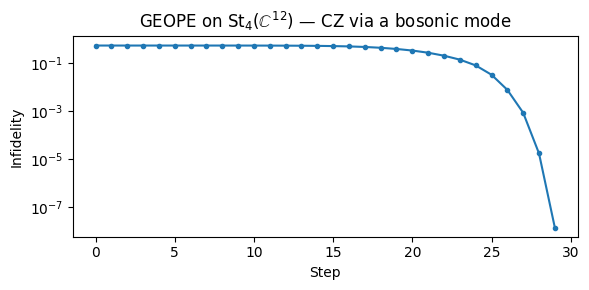

In [5]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.semilogy(opt.history.steps, 1 - np.asarray(opt.history.fidelities), "o-", markersize=3)
ax.set_xlabel("Step")
ax.set_ylabel("Infidelity")
ax.set_title("GEOPE on St$_4(\\mathbb{C}^{12})$ — CZ via a bosonic mode")
plt.tight_layout()
plt.show()